In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from Frquencies_plot_func import plot_frequencies_aa_pos,plot_corr_aa_pos

import os

from seq_utils import letters_to_nums, sequences_from_fasta, one_hot_seq_batch
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult,plot_projected_pca_time
import sys
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from model_PCA_correlation import AttentionModel_PCA
from dcascore import *
from utils import read_fasta_alignment, remove_duplicate_sequences, add_PCA_coords,quickread,pca_kmeans_analysis, plot_clusters_2d,get_PCA_grid_coords, get_proj_pca_coords, wasserstein_pca_distance


In [2]:

# ----- Load train sequences -----
family = 'PF00014'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\PCA_gen_ai\PCA_gen_AI\CODE\DataAttentionDCA\PF00014\PF00014.fasta"
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
_,W=quickread(file_test_data)
W=W/W.sum()
print(W)
train_sequences = sequences_from_fasta(file_test_data)
train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
    # remove non capital letters - '-' considered as capital letter
train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
train_sequences_num=np.array(train_sequences_num)


Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.3729949784786266
Computed theta: 0.32600975084432116


100%|██████████| 14502/14502 [00:09<00:00, 1509.07it/s]


3265.70225762244
[4.93891696e-06 7.50521695e-07 2.18723465e-05 ... 1.02070950e-04
 1.02070950e-04 2.75867434e-06]


In [7]:

results, pca, scaler=pca_kmeans_analysis(train_sequences_num,W,n_components=50,n_clusters=3,return_pca=True)
#plot_clusters_2d(results)
ov= get_PCA_grid_coords(results["centers"],35,coords_min=results["min_pca_axe0"],coords_max=results["max_pca_axe0"])
print(results["centers"])
print(results["sizes"])
print(results["max_distances"])
print(ov)

[[ 5.66450569e+00  1.09607334e+01 -3.37210471e-01 -2.04066710e+00
   4.88900846e-01 -7.64882042e-01  9.00297916e-02  3.97568293e-01
  -1.29288009e-01 -7.94222551e-02  9.86512133e-01 -3.28487858e-01
   3.17581262e-01  1.76834887e-01  7.72133366e-02  2.51909998e-01
  -2.80914532e-01  3.40896958e-01 -2.83569828e-01 -1.43191989e-01
   1.85911069e-02 -1.13251591e-01  1.13280097e-01  4.19116793e-02
  -2.75173999e-01 -1.27756681e-01 -1.41457771e-01  1.77891392e-01
   1.81901420e-01  4.48861189e-02 -5.54662742e-02 -4.76423896e-03
  -4.44935892e-02 -4.68832793e-02  8.65956039e-02 -1.75051984e-01
   4.05953722e-02 -4.21499768e-02  1.22809189e-01 -1.25938997e-01
  -1.16133300e-02 -4.89748114e-02  8.70331226e-02  5.98080654e-02
   1.40577042e-03  1.74020156e-02  1.57364915e-01 -9.70799136e-02
   5.45266149e-02 -7.40912464e-02]
 [-3.97845015e+00  7.84850381e-02 -2.08913561e-01  2.57477293e-01
   1.13034568e-01  8.71528685e-02  6.49876741e-02 -1.76230100e-02
   4.32496133e-02  1.46329434e-02 -8.8625

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.3713060337417181
Computed theta: 0.327492658211381


100%|██████████| 14502/14502 [00:10<00:00, 1442.48it/s]


3265.70225762244
[4.93891696e-06 7.50521695e-07 2.18723465e-05 ... 1.02070950e-04
 1.02070950e-04 2.75867434e-06]

Processing file: jdoms_J_julia.npz
(10000, 63)


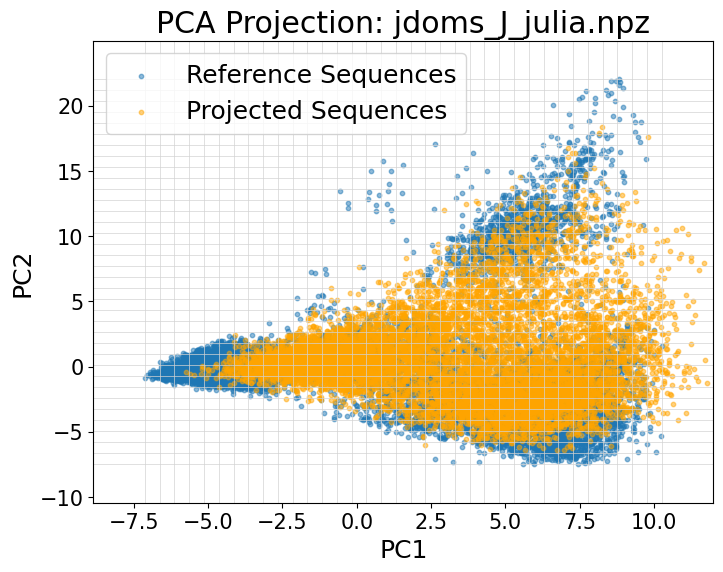

Linear fit slope = 0.9574, intercept = 0.0020, R² = 0.9981


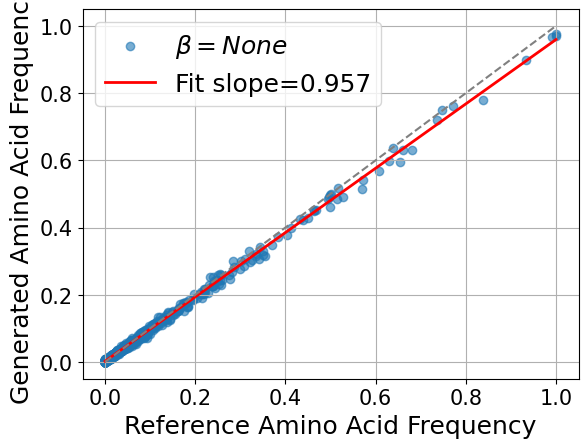

Linear fit slope = 0.8656, intercept = 0.0000, R² = 0.9369


C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


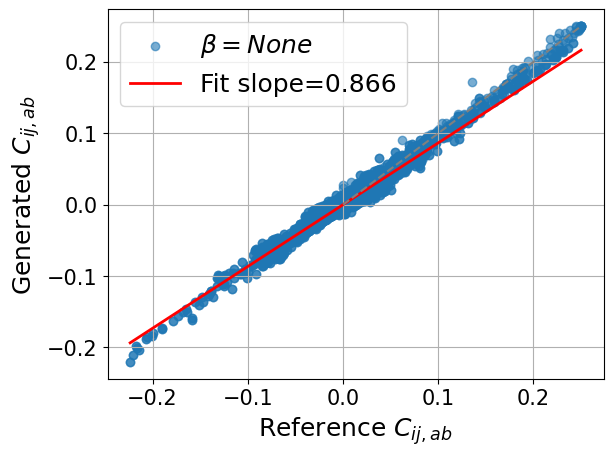


Processing file: jdoms_J_python.npz
(10000, 63)


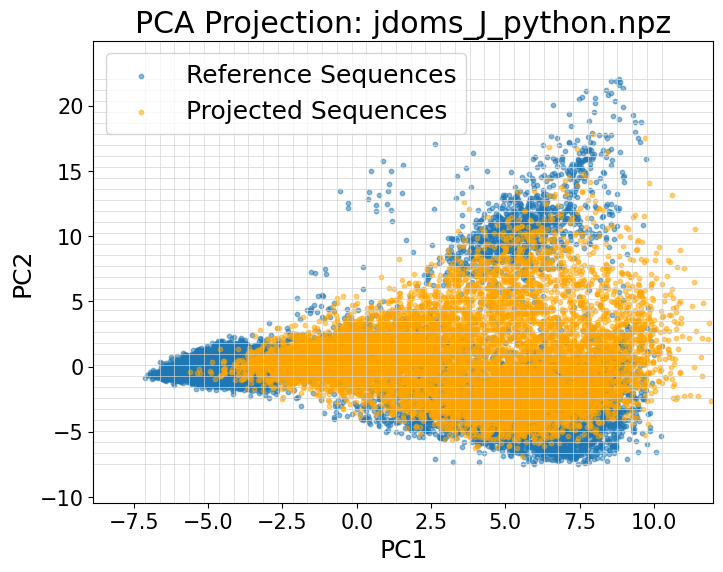

Linear fit slope = 0.9534, intercept = 0.0022, R² = 0.9969


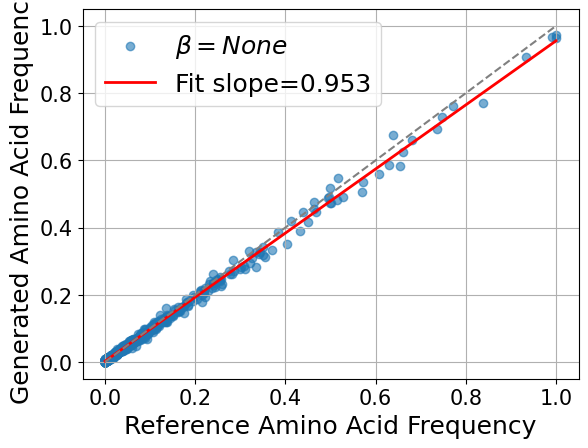

Linear fit slope = 0.8293, intercept = 0.0000, R² = 0.9097


C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


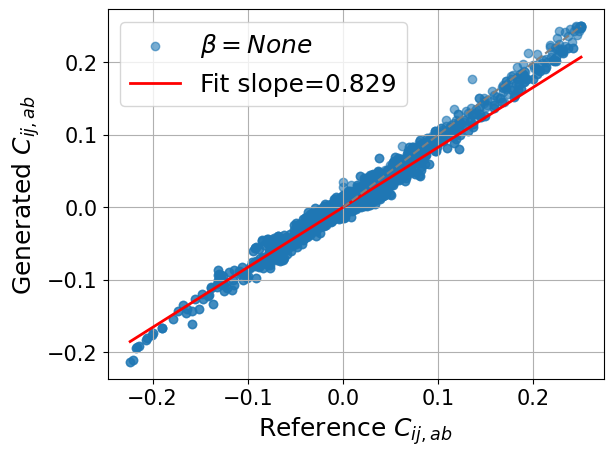

In [2]:
# ----- Paths -----
generated_dir = 'J_pagnani_jdoms_Jdirectautoreg'
#generated_dir = 'J_pagnani_jdoms_J_from_QKV_julia_autoreg'
generated_dir= "J_byhand"
generated_dir= "mod_alessandro_loss"
generated_dir = "plm_gen_vectorized"
generated_dir = "autoreg_gen"
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)

# ----- Load train sequences -----
family = 'PF00014'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\PCA_gen_ai\PCA_gen_AI\CODE\DataAttentionDCA\PF00014\PF00014.fasta"
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
_,W=quickread(file_test_data)
W=W/W.sum()
print(W)
train_sequences = sequences_from_fasta(file_test_data)
train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
    # remove non capital letters - '-' considered as capital letter
train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
train_sequences_num=np.array(train_sequences_num)
#print(train_sequences_num[:5])
# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy') or file.endswith('.npz'):
        print(f"\nProcessing file: {file}")
        
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        if file.endswith('.npz'):
            gen_sequences=gen_sequences["seq_array"]
            gen_sequences=np.array(gen_sequences,dtype=int)
            print(gen_sequences.shape)
        L=63
        if gen_sequences.shape[1] > L:
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        plot_projected_pca(
            sequences_reference=train_sequences_num,
            sequences_to_project=gen_sequences,
            title=title,
            Nbins=35,
            target_coords=target_coords)
        plot_frequencies_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)
        plot_corr_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)


Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37196031436250815
Computed theta: 0.32691659648800614


100%|██████████| 14502/14502 [00:09<00:00, 1572.29it/s]


3265.70225762244
[4.93891696e-06 7.50521695e-07 2.18723465e-05 ... 1.02070950e-04
 1.02070950e-04 2.75867434e-06]

Processing file: alessandro_plm_randinit_n_iter1500_nb_seq10000_b_1.npy


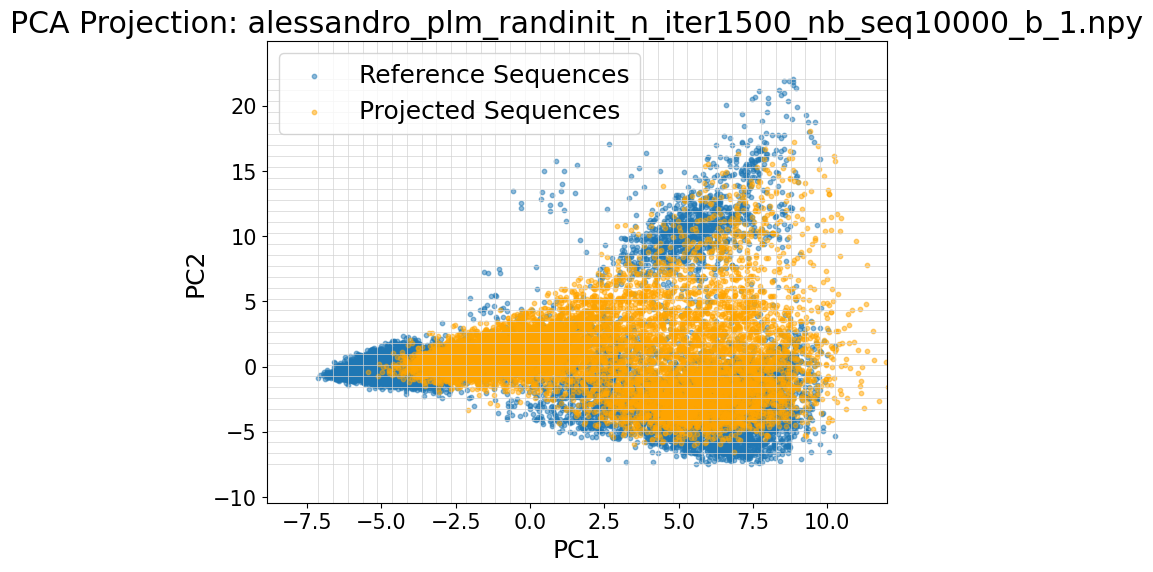

Linear fit slope = 0.9306, intercept = 0.0033, R² = 0.9819


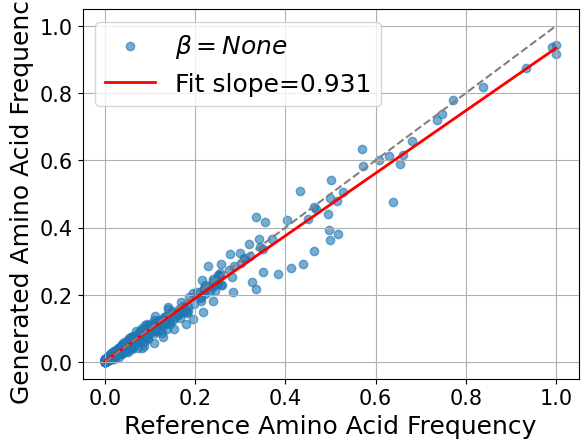

Linear fit slope = 0.7891, intercept = 0.0000, R² = 0.8638


C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


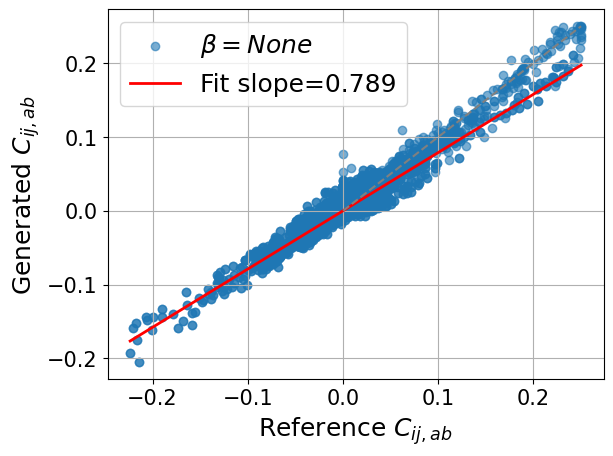


Processing file: Julia_imported_QKV_plm_randinit_n_iter1500_nb_seq10000_b_1.npy


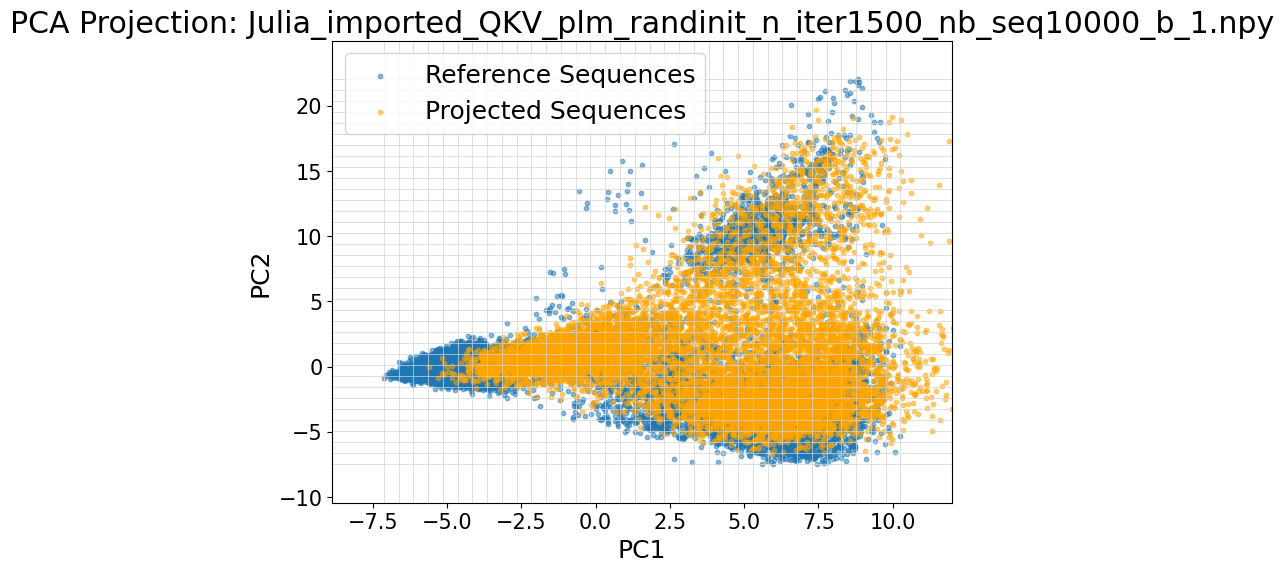

Linear fit slope = 0.9106, intercept = 0.0043, R² = 0.9934


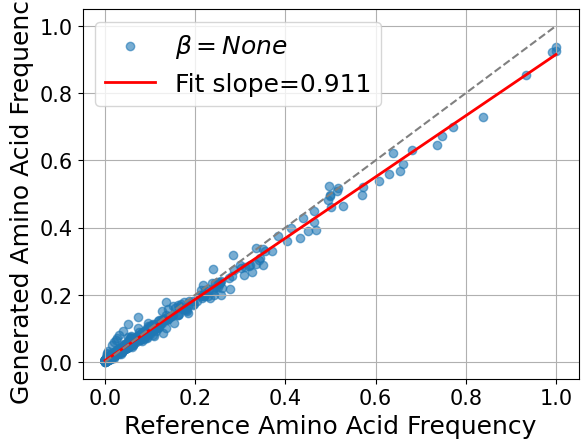

Linear fit slope = 0.8602, intercept = 0.0000, R² = 0.8665


C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


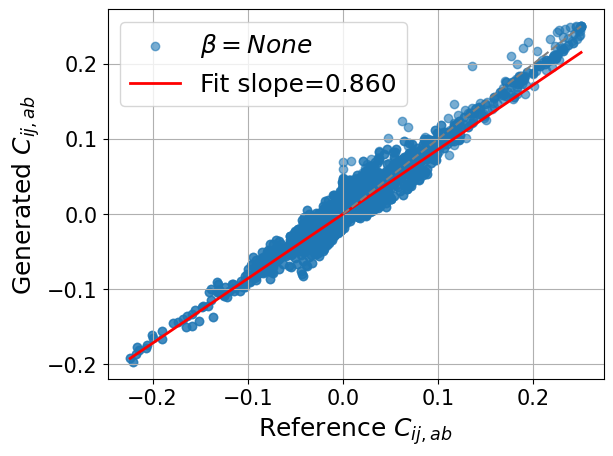


Processing file: modified_plm_randinit_n_iter1500_nb_seq10000_b_1.npy


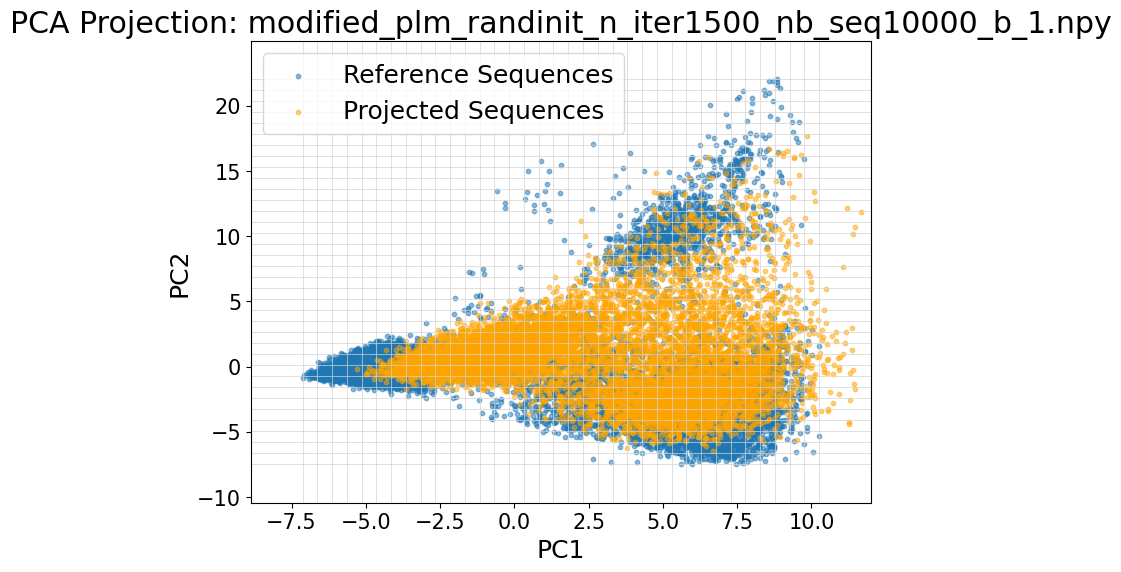

Linear fit slope = 0.9368, intercept = 0.0030, R² = 0.9890


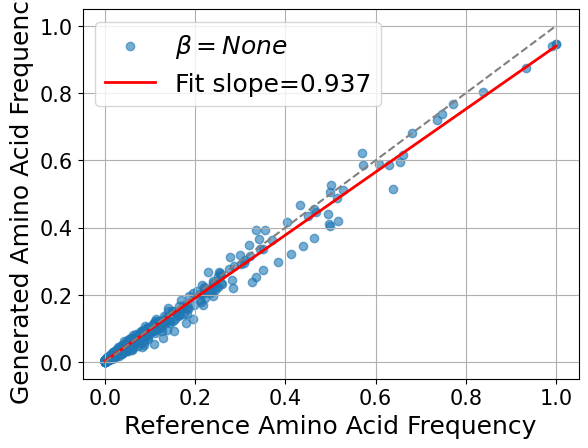

Linear fit slope = 0.8075, intercept = 0.0000, R² = 0.8702


C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


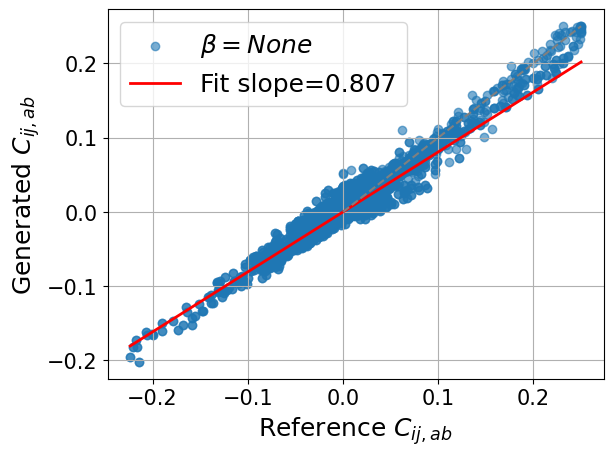

In [3]:
# ----- Paths -----
generated_dir = 'J_pagnani_jdoms_Jdirectautoreg'
#generated_dir = 'J_pagnani_jdoms_J_from_QKV_julia_autoreg'
generated_dir= "J_byhand"
generated_dir= "mod_alessandro_loss"
generated_dir = "plm_gen_vectorized"
#generated_dir = "autoreg_gen"
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)

# ----- Load train sequences -----
family = 'PF00014'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\PCA_gen_ai\PCA_gen_AI\CODE\DataAttentionDCA\PF00014\PF00014.fasta"
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
_,W=quickread(file_test_data)
W=W/W.sum()
print(W)
train_sequences = sequences_from_fasta(file_test_data)
train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
    # remove non capital letters - '-' considered as capital letter
train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
train_sequences_num=np.array(train_sequences_num)
#print(train_sequences_num[:5])
# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy') or file.endswith('.npz'):
        print(f"\nProcessing file: {file}")
        
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        if file.endswith('.npz'):
            gen_sequences=gen_sequences["seq_array"]
            gen_sequences=np.array(gen_sequences,dtype=int)
            print(gen_sequences.shape)
        L=63
        if gen_sequences.shape[1] > L:
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        plot_projected_pca(
            sequences_reference=train_sequences_num,
            sequences_to_project=gen_sequences,
            title=title,
            Nbins=35,
            target_coords=target_coords)
        plot_frequencies_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)
        plot_corr_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)


Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37198317460317454
Computed theta: 0.3268965058156753


100%|██████████| 14502/14502 [00:14<00:00, 991.49it/s] 


3265.70225762244
[4.93891696e-06 7.50521695e-07 2.18723465e-05 ... 1.02070950e-04
 1.02070950e-04 2.75867434e-06]

Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_1000.0_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


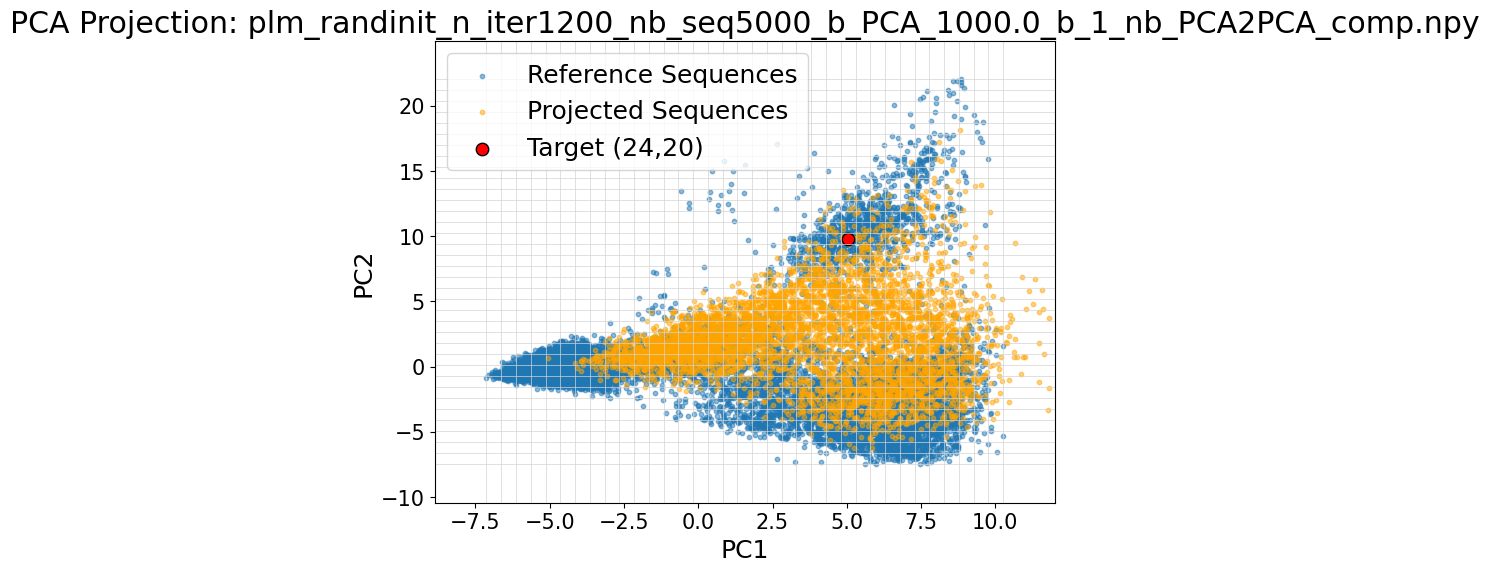

Linear fit slope = 0.8447, intercept = 0.0074, R² = 0.9557


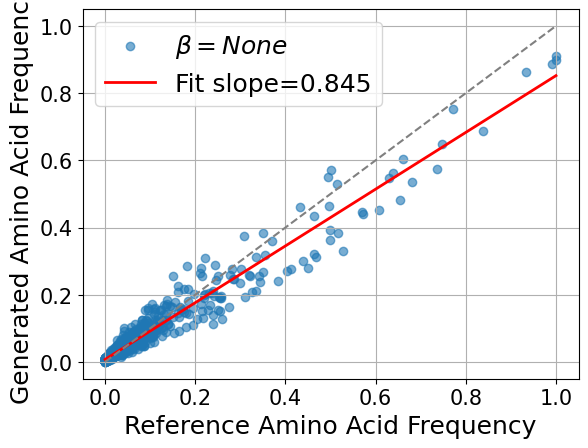


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_10000.0_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


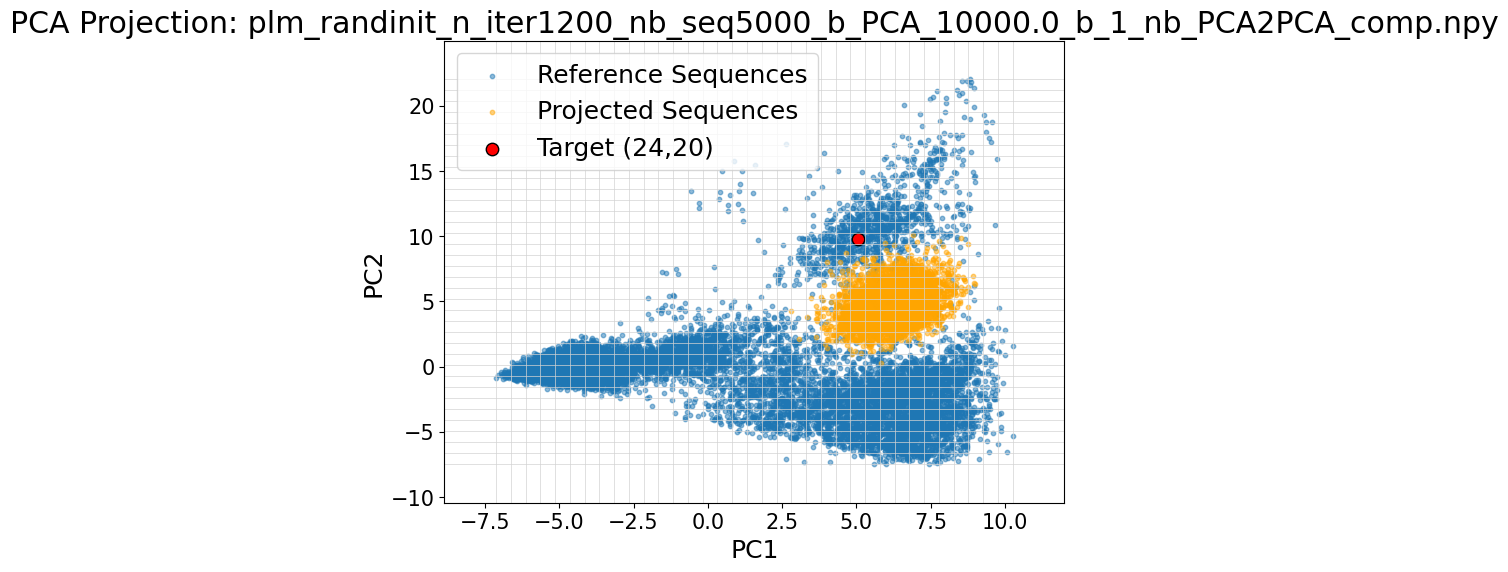

Linear fit slope = 0.2854, intercept = 0.0340, R² = 0.0468


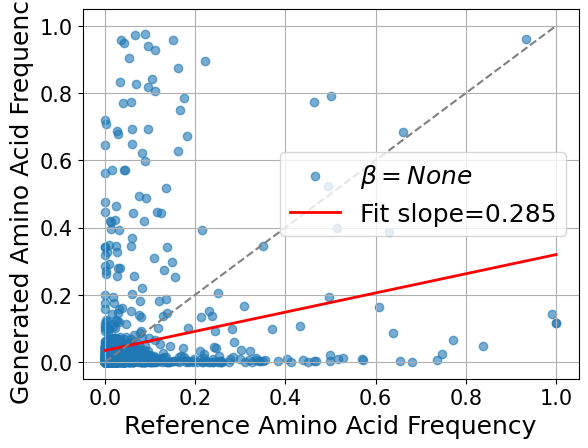


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_100000.0_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


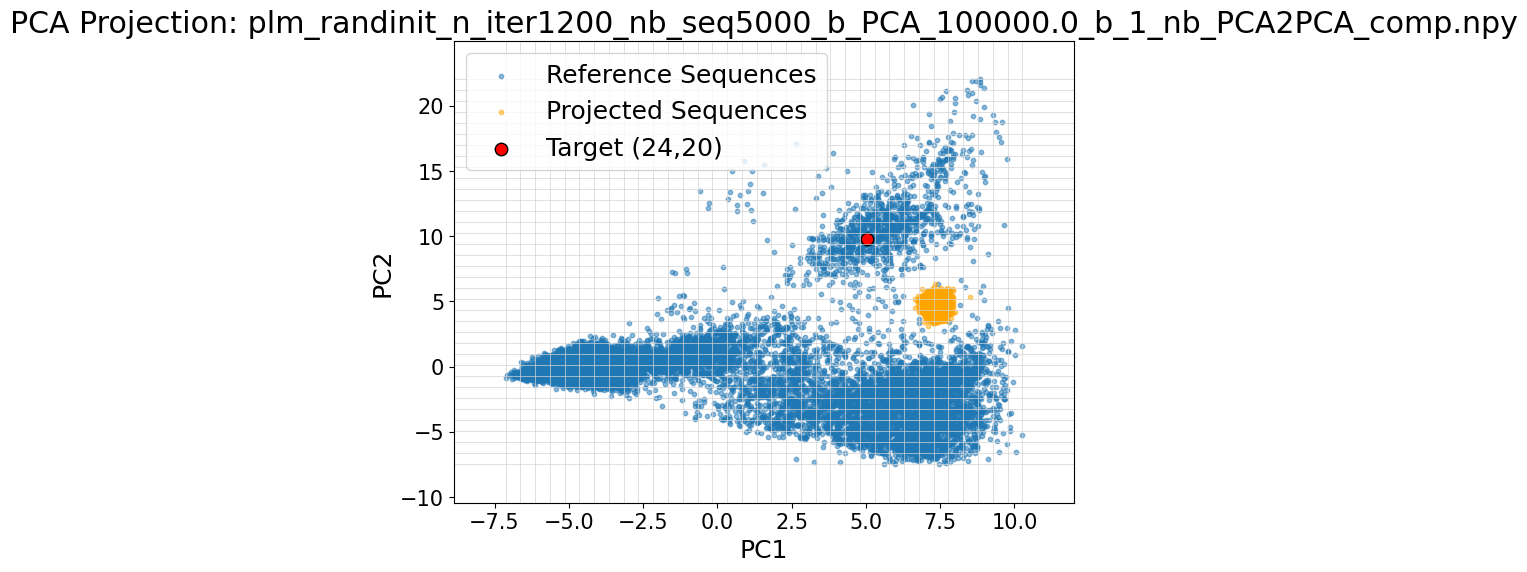

Linear fit slope = 0.1112, intercept = 0.0423, R² = 0.0037


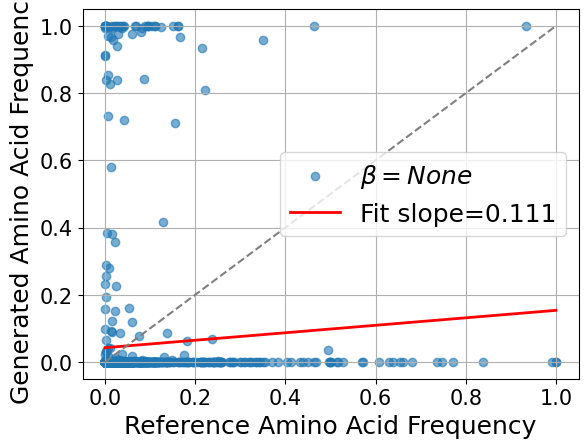


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_10_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


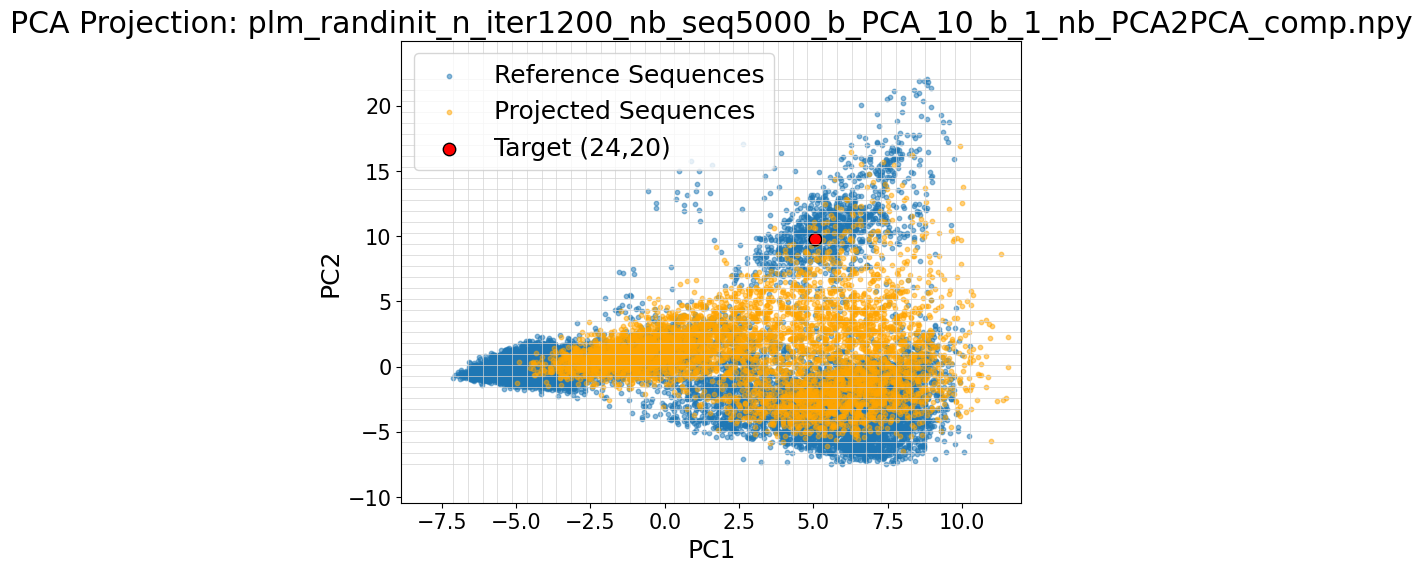

Linear fit slope = 0.8707, intercept = 0.0062, R² = 0.9908


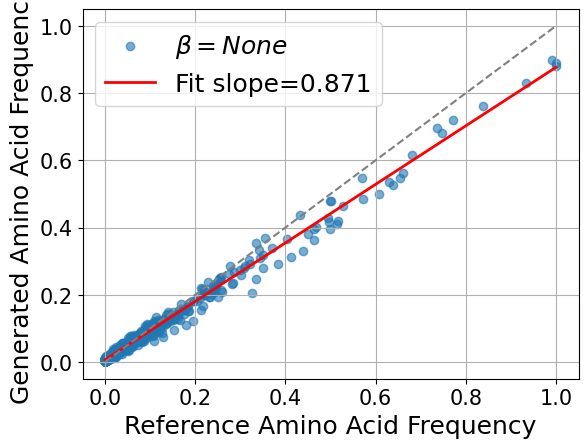


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_1_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


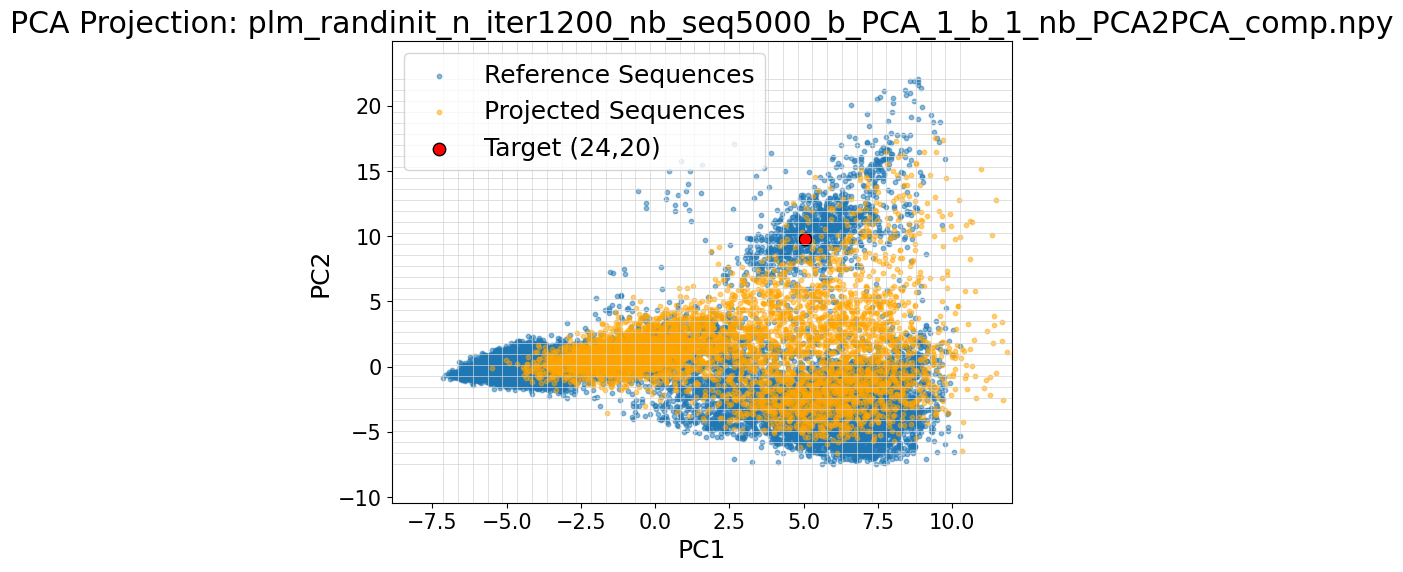

Linear fit slope = 0.8782, intercept = 0.0058, R² = 0.9787


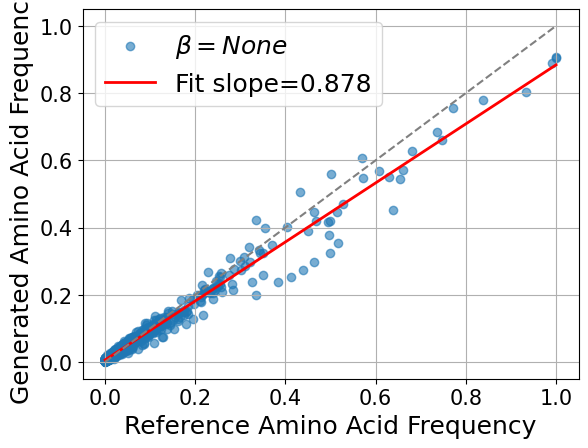


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_3000.0_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


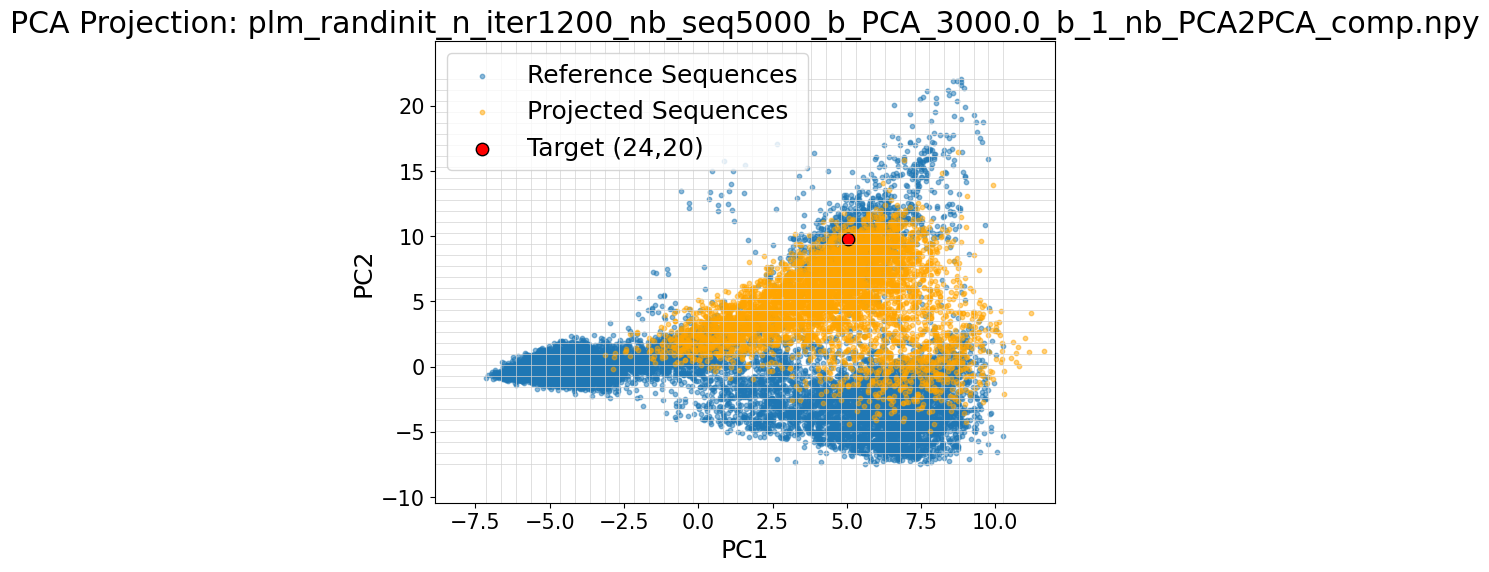

Linear fit slope = 0.7953, intercept = 0.0097, R² = 0.6127


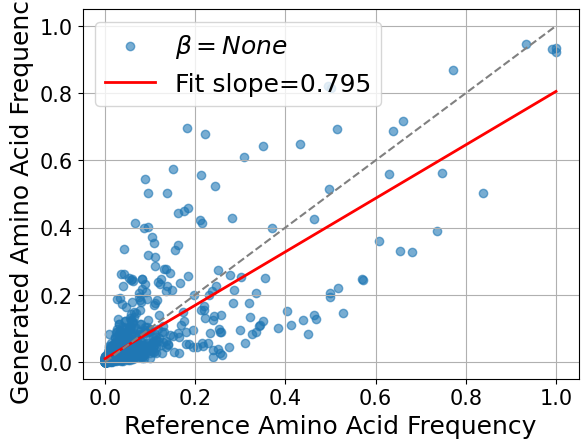


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_4000.0_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


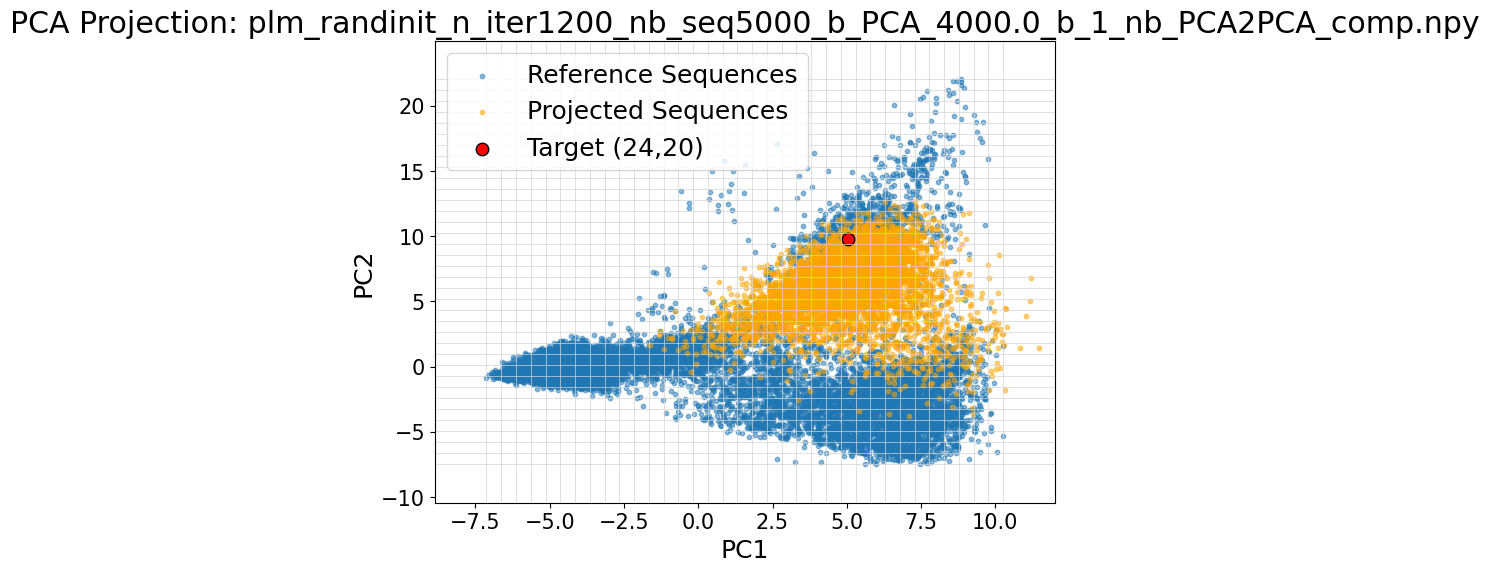

Linear fit slope = 0.7361, intercept = 0.0126, R² = 0.4450


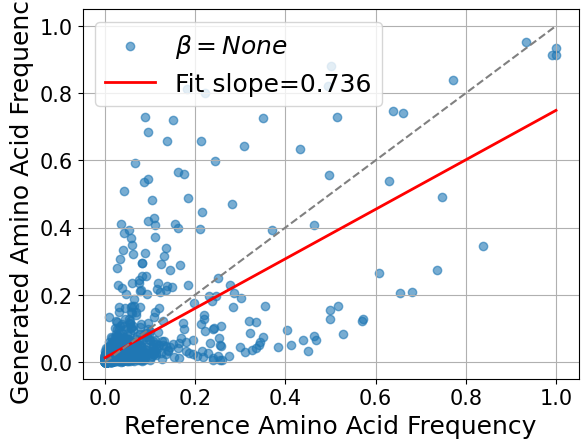


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_5000.0_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


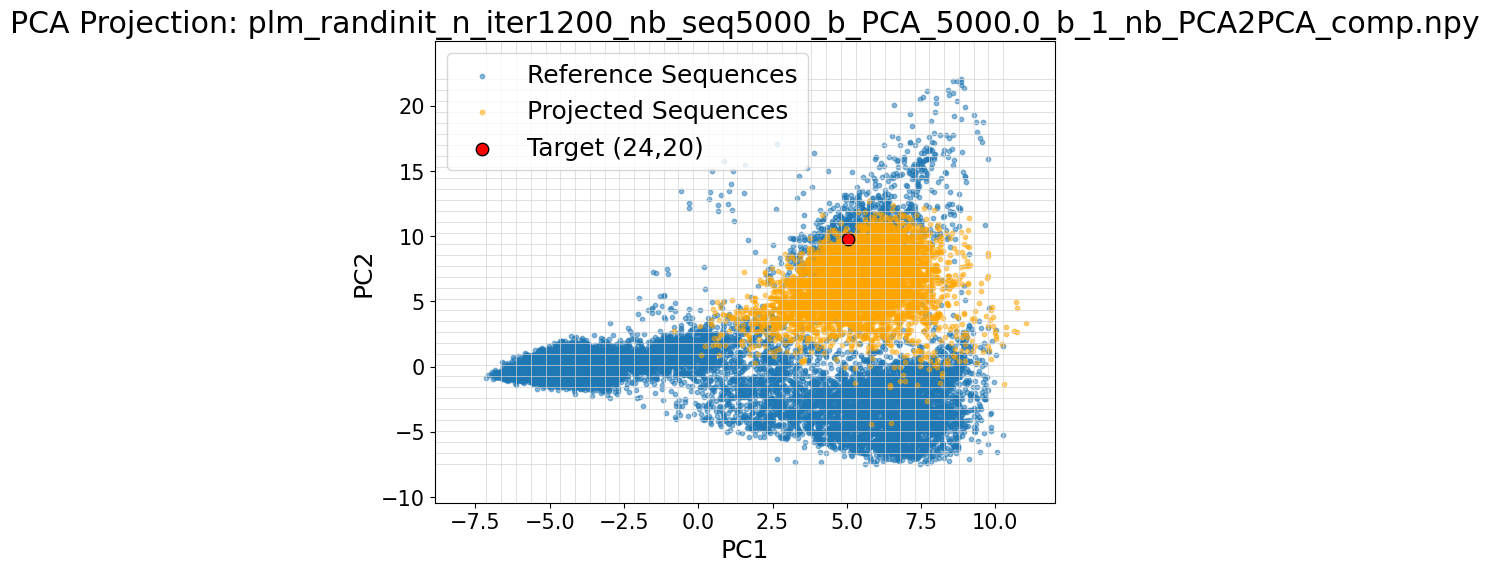

Linear fit slope = 0.6715, intercept = 0.0156, R² = 0.3371


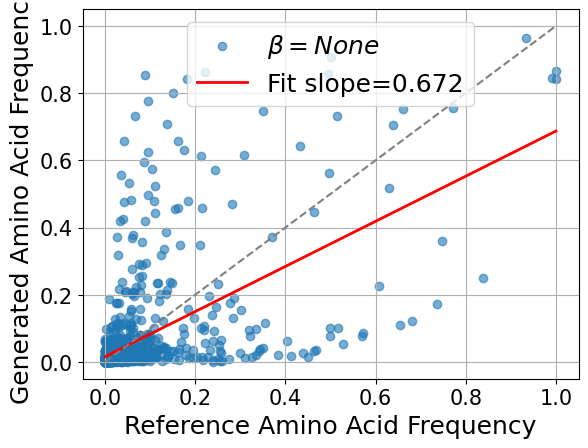


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_50_b_1_nb_PCA2PCA_comp.npy
aaaaaa (5000, 65)
teststsetse


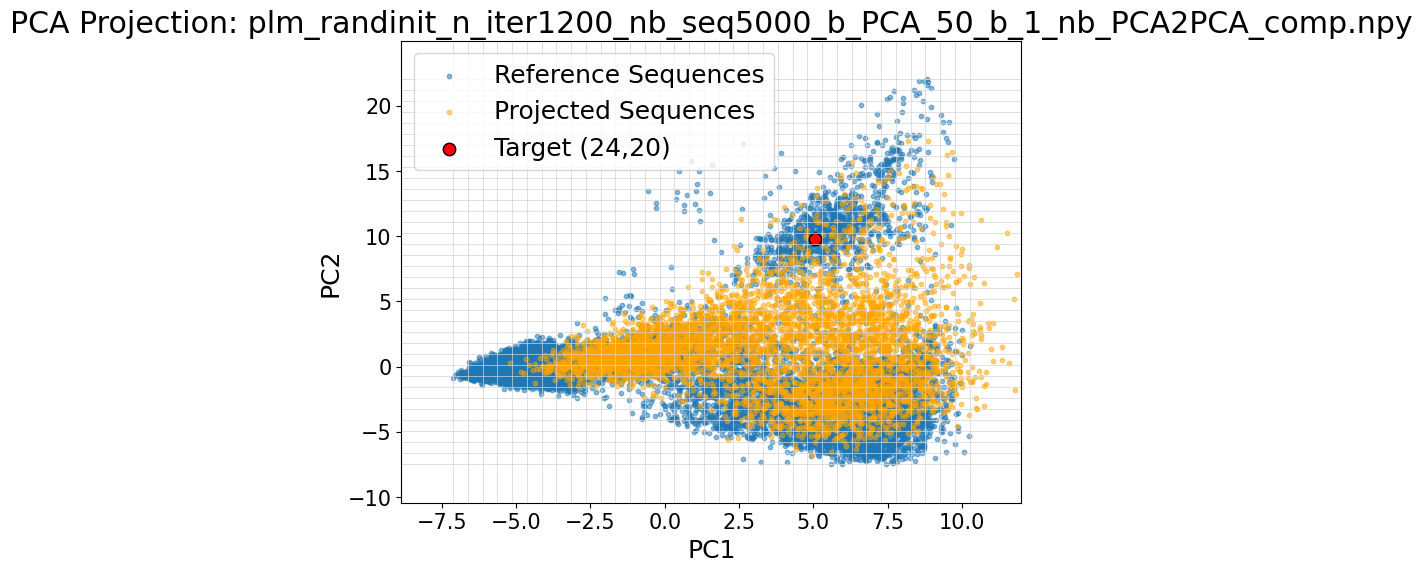

Linear fit slope = 0.8556, intercept = 0.0069, R² = 0.9921


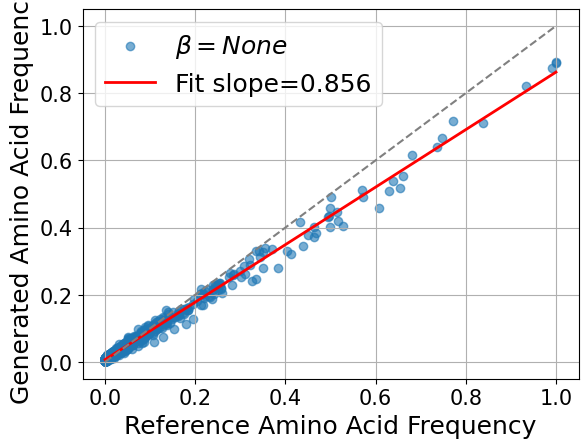

In [19]:
# ----- Paths -----
generated_dir = 'J_pagnani_jdoms_Jdirectautoreg'
#generated_dir = 'J_pagnani_jdoms_J_from_QKV_julia_autoreg'
generated_dir= "J_byhand"
generated_dir= "mod_alessandro_loss"
generated_dir = "plm_gen_vectorized"
generated_dir = "generated_vect_sequences_2model_pretrainedPCA_comp"
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)

# ----- Load train sequences -----
family = 'PF00014'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\PCA_gen_ai\PCA_gen_AI\CODE\DataAttentionDCA\PF00014\PF00014.fasta"
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
_,W=quickread(file_test_data)
W=W/W.sum()
print(W)
train_sequences = sequences_from_fasta(file_test_data)
train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
    # remove non capital letters - '-' considered as capital letter
train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
train_sequences_num=np.array(train_sequences_num)
#print(train_sequences_num[:5])
# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy') or file.endswith('.npz'):
        print(f"\nProcessing file: {file}")
        
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        if file.endswith('.npz'):
            gen_sequences=gen_sequences["seq_array"]
            gen_sequences=np.array(gen_sequences,dtype=int)
            print(gen_sequences.shape)
        L=63

        print("aaaaaa",gen_sequences.shape)
        if gen_sequences.shape[1] > L:
            print("teststsetse")
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        plot_projected_pca(
            sequences_reference=train_sequences_num,
            sequences_to_project=gen_sequences,
            title=title,
            Nbins=35,
            target_coords=target_coords)
        plot_frequencies_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)
        #plot_corr_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)



Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_10_b_1_nb_PCA5PCA_comp.npy
aaaaaa (5000, 68)
teststsetse

--- PCA Cluster Comparison ---
Cluster #: 0
Target (Cluster Center) coords: [ 5.35926869  9.86656692 -3.79554281  3.67725899 -1.4180107 ]

--- Training Set Stats ---
Number of training points in cluster: 909
RMS distance (train → target): 4.6488

--- Generated Set Stats ---
Number of generated sequences: 5000
Mean PCA coords of generated set: [ 3.02809365  1.38544084 -0.83260456 -0.80576044 -0.0041059 ]
RMS distance (gen → target): 12.3214

--- Distribution Comparison ---
Wasserstein distances per PCA component (first 5):
  Component 1: 2.6251
  Component 2: 8.4997
  Component 3: 2.9633
  Component 4: 4.4849
  Component 5: 1.4150
Mean Wasserstein distance: 3.9976
-------------------------------

Linear fit slope = 0.8783, intercept = 0.0058, R² = 0.9790


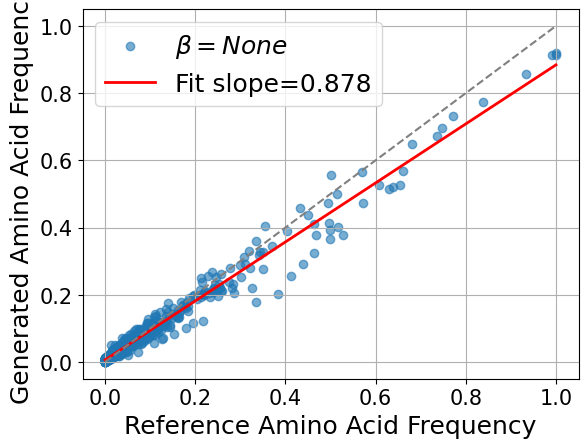

Linear fit slope = 0.5872, intercept = 0.0197, R² = 0.5525


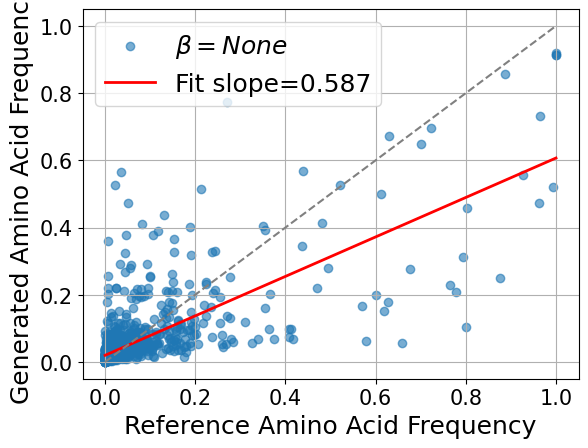


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_50_b_1_nb_PCA5PCA_comp.npy
aaaaaa (5000, 68)
teststsetse

--- PCA Cluster Comparison ---
Cluster #: 0
Target (Cluster Center) coords: [ 5.35926869  9.86656692 -3.79554281  3.67725899 -1.4180107 ]

--- Training Set Stats ---
Number of training points in cluster: 909
RMS distance (train → target): 4.6488

--- Generated Set Stats ---
Number of generated sequences: 5000
Mean PCA coords of generated set: [ 5.57956487  1.06889099 -1.06369628 -0.47657114 -0.20331272]
RMS distance (gen → target): 11.7715

--- Distribution Comparison ---
Wasserstein distances per PCA component (first 5):
  Component 1: 1.4671
  Component 2: 8.8075
  Component 3: 2.7321
  Component 4: 4.1557
  Component 5: 1.2157
Mean Wasserstein distance: 3.6756
-------------------------------

Linear fit slope = 0.7194, intercept = 0.0134, R² = 0.8034


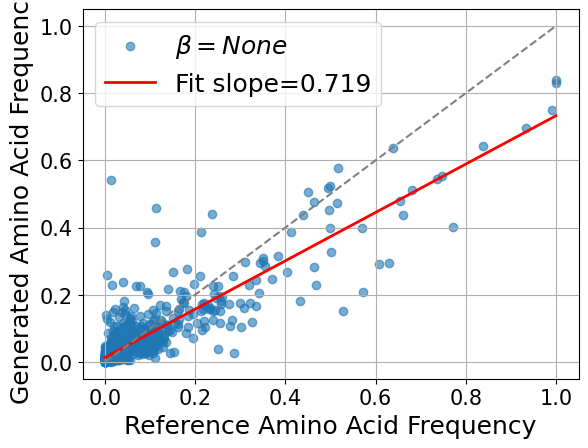

Linear fit slope = 0.4881, intercept = 0.0244, R² = 0.4669


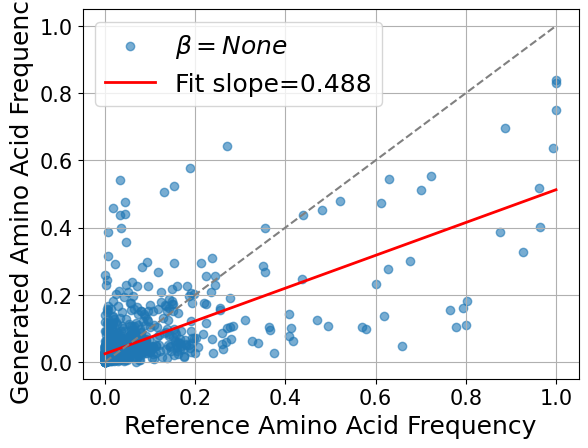

In [ ]:
n_bins=35
nb_PCA_comp=50
# ----- Paths -----
generated_dir = 'J_pagnani_jdoms_Jdirectautoreg'
#generated_dir = 'J_pagnani_jdoms_J_from_QKV_julia_autoreg'
generated_dir= "J_byhand"
generated_dir= "mod_alessandro_loss"
generated_dir = "plm_gen_vectorized"
generated_dir = "generated_vect_sequences_2model_pretrainedPCA_comp"
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)
n_pca_comp=5

# ----- Load train sequences -----
# family = 'PF00014'
# file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\PCA_gen_ai\PCA_gen_AI\CODE\DataAttentionDCA\PF00014\PF00014.fasta"
# family = 'jdoms_bacteria_train2'
# file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
# _,W=quickread(file_test_data)
# W=W/W.sum()
# print(W)
# train_sequences = sequences_from_fasta(file_test_data)
# train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
#     # remove non capital letters - '-' considered as capital letter
# train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
# train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
# train_sequences_num=np.array(train_sequences_num)
#print(train_sequences_num[:5])
# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy') or file.endswith('.npz'):
        print(f"\nProcessing file: {file}")
        cluster_nb=0
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        if file.endswith('.npz'):
            gen_sequences=gen_sequences["seq_array"]
            gen_sequences=np.array(gen_sequences,dtype=int)
            print(gen_sequences.shape)
        L=63

        print("aaaaaa",gen_sequences.shape)
        if gen_sequences.shape[1] > L:
            print("teststsetse")
            target_coords = gen_sequences[0, -n_pca_comp:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-n_pca_comp]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        target_coords=np.array(results["centers"][cluster_nb])
        cluster_weights=np.array(results["weights"][cluster_nb])
        cluster_weights=cluster_weights/np.sum(cluster_weights)
        cluster_sequences=np.array(results["sequences"][cluster_nb])
        cluster_train_points=np.array(results["points"][cluster_nb])
        rms_train_targ=np.sqrt(np.mean(np.sum((cluster_train_points-target_coords)**2,axis=1)))
        pca_coord_gen_seq=get_proj_pca_coords(gen_sequences,pca,scaler)
        mean_pca_target_gen=np.mean(pca_coord_gen_seq,axis=0)
        rms_gen_targ=np.sqrt(np.mean(np.sum((pca_coord_gen_seq-target_coords)**2,axis=1)))
        wess_dist= wasserstein_pca_distance(cluster_train_points,pca_coord_gen_seq,n_components=5)
        print("\n--- PCA Cluster Comparison ---")
        print(f"Cluster #: {cluster_nb}")
        print(f"Target (Cluster Center) coords: {target_coords}")

        print("\n--- Training Set Stats ---")
        print(f"Number of training points in cluster: {len(cluster_train_points)}")
        print(f"RMS distance (train → target): {rms_train_targ:.4f}")

        print("\n--- Generated Set Stats ---")
        print(f"Number of generated sequences: {len(pca_coord_gen_seq)}")
        print(f"Mean PCA coords of generated set: {mean_pca_target_gen}")
        print(f"RMS distance (gen → target): {rms_gen_targ:.4f}")

        print("\n--- Distribution Comparison ---")
        print("Wasserstein distances per PCA component (first 5):")
        for comp, dist in wess_dist[0].items():
            print(f"  Component {comp+1}: {dist:.4f}")
        print(f"Mean Wasserstein distance: {wess_dist[1]:.4f}")
        print("-------------------------------\n")
        plot_frequencies_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)
        plot_frequencies_aa_pos(gen_sequences,cluster_sequences,W=cluster_weights)
        #plot_corr_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)



Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_10_b_1_nb_PCA50PCA_comp.npy
aaaaaa (5000, 113)
teststsetse
[26 24 16 17 16 11 13  4 11 20 19 18 12  7 13 15  9 20 14  7 14 10 20  2
 15  3 25  6 20 19 16 10 21 11 13  9 14 14 16 22 18 21  9 17 14 18 11 13
 13 14]

--- PCA Cluster Comparison ---
Cluster #: 0
Target (Cluster Center) coords: [ 5.66450569e+00  1.09607334e+01 -3.37210471e-01 -2.04066710e+00
  4.88900846e-01 -7.64882042e-01  9.00297916e-02  3.97568293e-01
 -1.29288009e-01 -7.94222551e-02  9.86512133e-01 -3.28487858e-01
  3.17581262e-01  1.76834887e-01  7.72133366e-02  2.51909998e-01
 -2.80914532e-01  3.40896958e-01 -2.83569828e-01 -1.43191989e-01
  1.85911069e-02 -1.13251591e-01  1.13280097e-01  4.19116793e-02
 -2.75173999e-01 -1.27756681e-01 -1.41457771e-01  1.77891392e-01
  1.81901420e-01  4.48861189e-02 -5.54662742e-02 -4.76423896e-03
 -4.44935892e-02 -4.68832793e-02  8.65956039e-02 -1.75051984e-01
  4.05953722e-02 -4.21499768e-02  1.22809189e-01 -1.25938997e-01
 

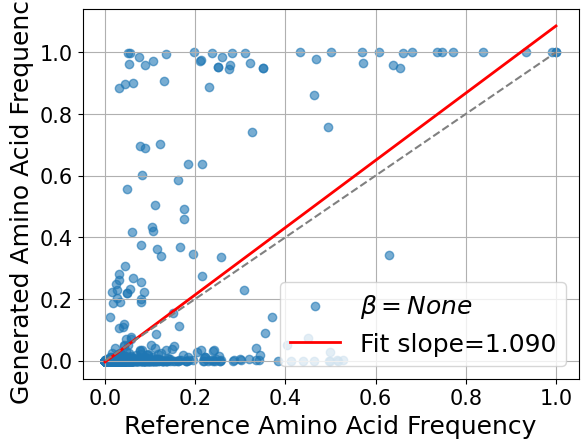

Linear fit slope = 0.8080, intercept = 0.0091, R² = 0.2614


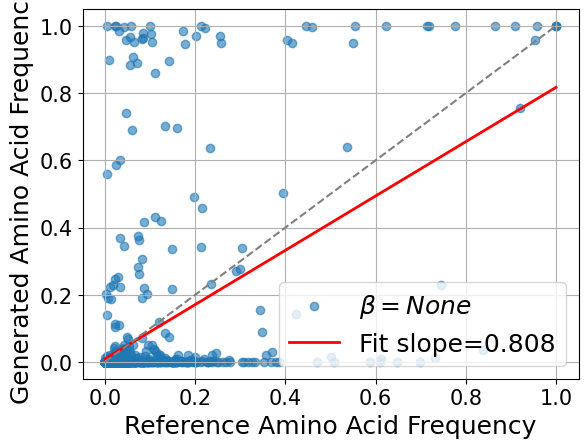

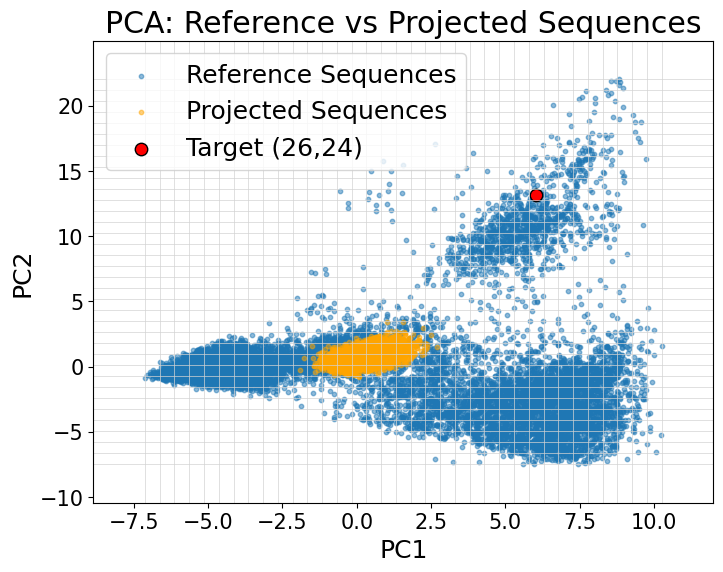


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_1_b_1_nb_PCA50PCA_comp.npy
aaaaaa (5000, 113)
teststsetse
[26 24 16 17 16 11 13  4 11 20 19 18 12  7 13 15  9 20 14  7 14 10 20  2
 15  3 25  6 20 19 16 10 21 11 13  9 14 14 16 22 18 21  9 17 14 18 11 13
 13 14]

--- PCA Cluster Comparison ---
Cluster #: 0
Target (Cluster Center) coords: [ 5.66450569e+00  1.09607334e+01 -3.37210471e-01 -2.04066710e+00
  4.88900846e-01 -7.64882042e-01  9.00297916e-02  3.97568293e-01
 -1.29288009e-01 -7.94222551e-02  9.86512133e-01 -3.28487858e-01
  3.17581262e-01  1.76834887e-01  7.72133366e-02  2.51909998e-01
 -2.80914532e-01  3.40896958e-01 -2.83569828e-01 -1.43191989e-01
  1.85911069e-02 -1.13251591e-01  1.13280097e-01  4.19116793e-02
 -2.75173999e-01 -1.27756681e-01 -1.41457771e-01  1.77891392e-01
  1.81901420e-01  4.48861189e-02 -5.54662742e-02 -4.76423896e-03
 -4.44935892e-02 -4.68832793e-02  8.65956039e-02 -1.75051984e-01
  4.05953722e-02 -4.21499768e-02  1.22809189e-01 -1.25938997e-01
 -

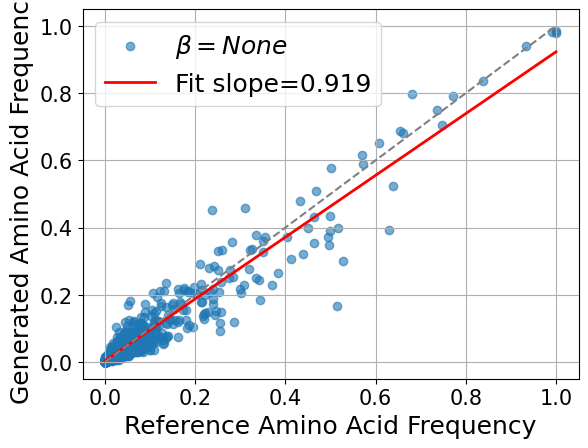

Linear fit slope = 0.6287, intercept = 0.0177, R² = 0.5086


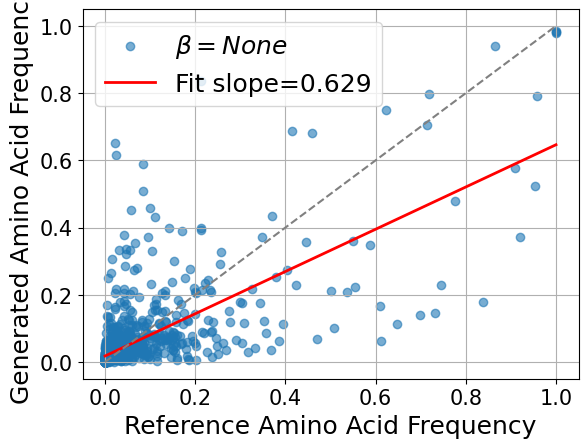

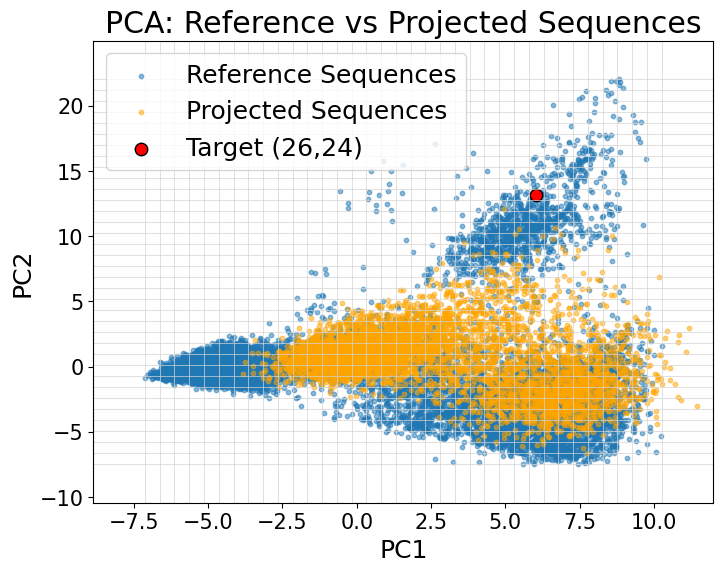


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_50_b_1_nb_PCA50PCA_comp.npy
aaaaaa (5000, 113)
teststsetse
[26 24 16 17 16 11 13  4 11 20 19 18 12  7 13 15  9 20 14  7 14 10 20  2
 15  3 25  6 20 19 16 10 21 11 13  9 14 14 16 22 18 21  9 17 14 18 11 13
 13 14]

--- PCA Cluster Comparison ---
Cluster #: 0
Target (Cluster Center) coords: [ 5.66450569e+00  1.09607334e+01 -3.37210471e-01 -2.04066710e+00
  4.88900846e-01 -7.64882042e-01  9.00297916e-02  3.97568293e-01
 -1.29288009e-01 -7.94222551e-02  9.86512133e-01 -3.28487858e-01
  3.17581262e-01  1.76834887e-01  7.72133366e-02  2.51909998e-01
 -2.80914532e-01  3.40896958e-01 -2.83569828e-01 -1.43191989e-01
  1.85911069e-02 -1.13251591e-01  1.13280097e-01  4.19116793e-02
 -2.75173999e-01 -1.27756681e-01 -1.41457771e-01  1.77891392e-01
  1.81901420e-01  4.48861189e-02 -5.54662742e-02 -4.76423896e-03
 -4.44935892e-02 -4.68832793e-02  8.65956039e-02 -1.75051984e-01
  4.05953722e-02 -4.21499768e-02  1.22809189e-01 -1.25938997e-01
 

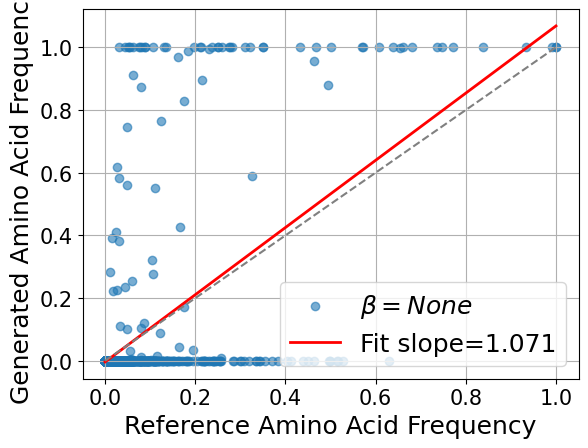

Linear fit slope = 0.8135, intercept = 0.0089, R² = 0.2285


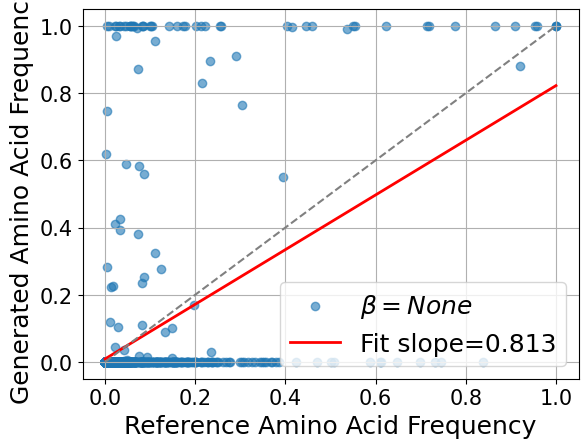

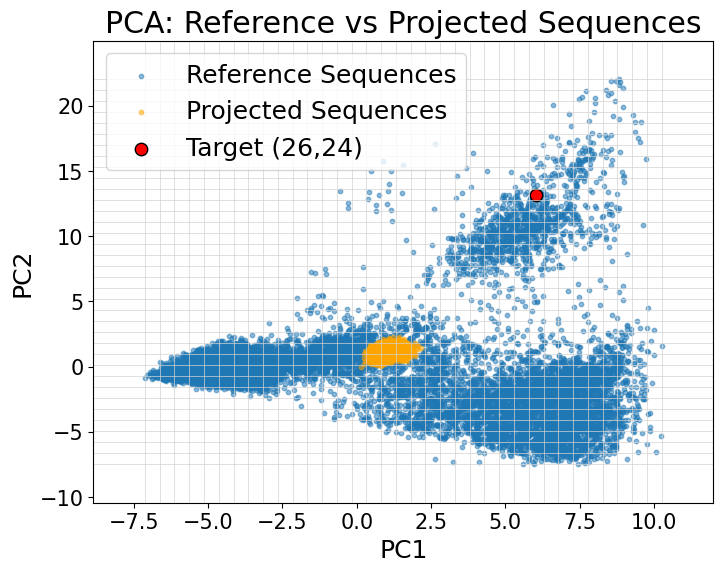


Processing file: plm_randinit_n_iter1200_nb_seq5000_b_PCA_5_b_1_nb_PCA50PCA_comp.npy
aaaaaa (5000, 113)
teststsetse
[26 24 16 17 16 11 13  4 11 20 19 18 12  7 13 15  9 20 14  7 14 10 20  2
 15  3 25  6 20 19 16 10 21 11 13  9 14 14 16 22 18 21  9 17 14 18 11 13
 13 14]

--- PCA Cluster Comparison ---
Cluster #: 0
Target (Cluster Center) coords: [ 5.66450569e+00  1.09607334e+01 -3.37210471e-01 -2.04066710e+00
  4.88900846e-01 -7.64882042e-01  9.00297916e-02  3.97568293e-01
 -1.29288009e-01 -7.94222551e-02  9.86512133e-01 -3.28487858e-01
  3.17581262e-01  1.76834887e-01  7.72133366e-02  2.51909998e-01
 -2.80914532e-01  3.40896958e-01 -2.83569828e-01 -1.43191989e-01
  1.85911069e-02 -1.13251591e-01  1.13280097e-01  4.19116793e-02
 -2.75173999e-01 -1.27756681e-01 -1.41457771e-01  1.77891392e-01
  1.81901420e-01  4.48861189e-02 -5.54662742e-02 -4.76423896e-03
 -4.44935892e-02 -4.68832793e-02  8.65956039e-02 -1.75051984e-01
  4.05953722e-02 -4.21499768e-02  1.22809189e-01 -1.25938997e-01
 -

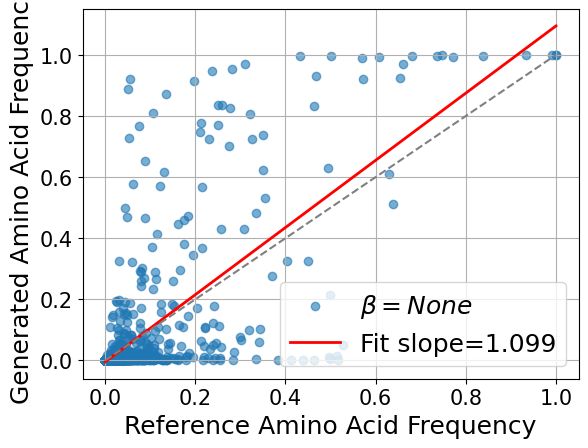

Linear fit slope = 0.7814, intercept = 0.0104, R² = 0.3116


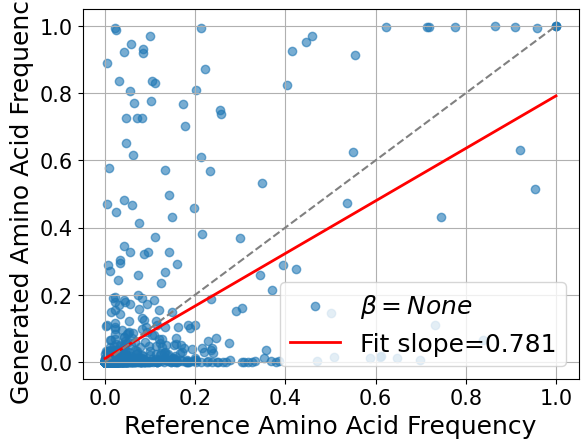

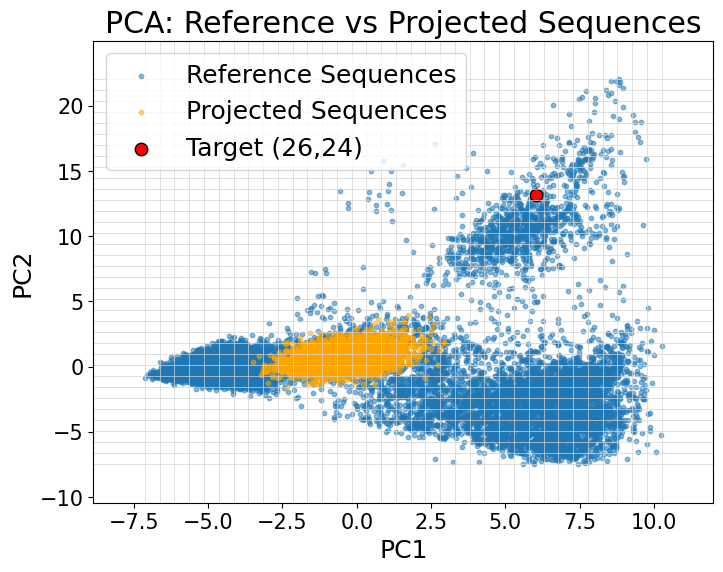

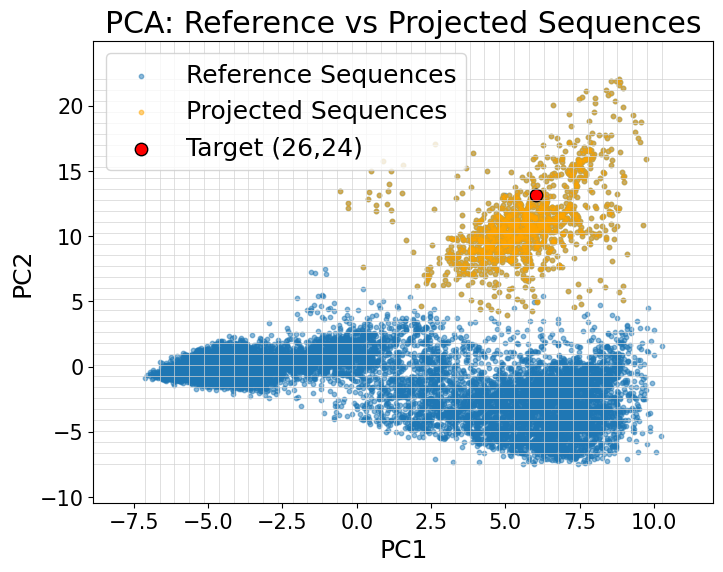

In [13]:
nb_PCA_comp=50
n_bins=35
# ----- Paths -----
generated_dir = 'J_pagnani_jdoms_Jdirectautoreg'
#generated_dir = 'J_pagnani_jdoms_J_from_QKV_julia_autoreg'
generated_dir= "J_byhand"
generated_dir= "mod_alessandro_loss"
generated_dir = "plm_gen_vectorized"
generated_dir = f"generated_vect_sequences_2model_pretrained_n_PCA{n_pca_comp}_n_bins{n_bins}PCA_comp"
generated_dir = f"generated_vect_sequences_Jcond_n_PCA{nb_PCA_comp}_n_bins{n_bins}PCA_comp"

cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)


# ----- Load train sequences -----
# family = 'PF00014'
# file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\PCA_gen_ai\PCA_gen_AI\CODE\DataAttentionDCA\PF00014\PF00014.fasta"
# family = 'jdoms_bacteria_train2'
# file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
# _,W=quickread(file_test_data)
# W=W/W.sum()
# print(W)
# train_sequences = sequences_from_fasta(file_test_data)
# train_sequences = [seq.replace('.', '') for seq in train_sequences]  # remove all dots
#     # remove non capital letters - '-' considered as capital letter
# train_sequences = [''.join([c for c in seq if c.isupper() or c == '-']) for seq in train_sequences]
# train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]
# train_sequences_num=np.array(train_sequences_num)
#print(train_sequences_num[:5])
# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy') or file.endswith('.npz'):
        print(f"\nProcessing file: {file}")
        cluster_nb=0
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        if file.endswith('.npz'):
            gen_sequences=gen_sequences["seq_array"]
            gen_sequences=np.array(gen_sequences,dtype=int)
            print(gen_sequences.shape)
        L=63

        print("aaaaaa",gen_sequences.shape)
        if gen_sequences.shape[1] > L:
            print("teststsetse")
            target_coords1 = gen_sequences[0, -n_pca_comp:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-n_pca_comp]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        print(target_coords1)
        target_coords=np.array(results["centers"][cluster_nb])
        cluster_weights=np.array(results["weights"][cluster_nb])
        cluster_weights=cluster_weights/np.sum(cluster_weights)
        cluster_sequences=np.array(results["sequences"][cluster_nb])
        cluster_train_points=np.array(results["points"][cluster_nb])
        rms_train_targ=np.sqrt(np.mean(np.sum((cluster_train_points-target_coords)**2,axis=1)))
        pca_coord_gen_seq=get_proj_pca_coords(gen_sequences,pca,scaler)
        mean_pca_target_gen=np.mean(pca_coord_gen_seq,axis=0)
        rms_gen_targ=np.sqrt(np.mean(np.sum((pca_coord_gen_seq-target_coords)**2,axis=1)))
        wess_dist= wasserstein_pca_distance(cluster_train_points,pca_coord_gen_seq,n_components=5)
        print("\n--- PCA Cluster Comparison ---")
        print(f"Cluster #: {cluster_nb}")
        print(f"Target (Cluster Center) coords: {target_coords}")

        print("\n--- Training Set Stats ---")
        print(f"Number of training points in cluster: {len(cluster_train_points)}")
        print(f"RMS distance (train → target): {rms_train_targ:.4f}")

        print("\n--- Generated Set Stats ---")
        print(f"Number of generated sequences: {len(pca_coord_gen_seq)}")
        print(f"Mean PCA coords of generated set: {mean_pca_target_gen}")
        print(f"RMS distance (gen → target): {rms_gen_targ:.4f}")

        print("\n--- Distribution Comparison ---")
        print("Wasserstein distances per PCA component (first 5):")
        for comp, dist in wess_dist[0].items():
            print(f"  Component {comp+1}: {dist:.4f}")
        print(f"Mean Wasserstein distance: {wess_dist[1]:.4f}")
        print("-------------------------------\n")
        plot_frequencies_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)
        plot_frequencies_aa_pos(gen_sequences,cluster_sequences,W=cluster_weights)
        plot_projected_pca(
            sequences_reference=train_sequences_num,
            sequences_to_project=gen_sequences,Nbins=35,target_coords=target_coords1[:2]
            )
        #plot_corr_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)
    
plot_projected_pca(
            sequences_reference=train_sequences_num,
            sequences_to_project=cluster_sequences,Nbins=35,target_coords=target_coords1[:2]
            )